# QCentroid Challenge: Detecting DDoS using Quantum-Inspired Machine Learning

The dataset consists of network flow records aggregated into 15-minute windows. Each window contains 100,000 flow rows, of which 1.5–2.5% are seeded DDoS attack flows concentrated into 2–4 short temporal bursts. The task is to identify which time windows contain a burst and which source IPs are responsible.

## Step 1: Feature Extraction and Binning
Each 15-minute window is divided into 1-second bins. Within each bin, 9 aggregate features are computed from the flows: 
$$\mathbf{x}(t) = \bigl[\text{flow count},\ \text{total packets},\ n_\text{src IPs},\ n_\text{dst IPs},\ n_\text{dst ports},\ \overline{\text{duration}},\ \overline{\text{pkt size}},\ \overline{\text{pkts/s}},\ \overline{\text{bytes/s}}\bigr]$$
Features expected to decrease during a DDoS burst (e.g. mean_duration, n_dst_ips) have their sign flipped so that all anomalies appear as positive deviations.

## Step 2: Z-score normalisation
A benign baseline $\mu_f(t)$ and $\sigma_f(t)$ is estimated per feature per time bin from 8 benign training files. Each attack file is then standardised against this baseline: $$z_f(t) = \frac{x_f(t) - \mu_f(t)}{\sigma_f(t)}$$.
This produces a 2D z-score image of shape T x F (900 x 9), where benign traffic looks like low-amplitude noise and a DDoS burst appears as a bright vertical stripe: many features simultaneously deviating from the benign baseline at the same time bins.

## Step 3: Image construction
The z-score image is clipped to [−5,5] and normalised to [0,1]: $$I(t, f) = \frac{\text{clip}(z_f(t), -5, 5) + 5}{10}$$. The image is then coarsened by averaging consecutive 5-second bins, reducing the time axis from 900 to 180 bins for computational tractability.

## Step 4: Quanvolutional Layer

A $2 \times 3$ patch (2 time bins $\times$ 3 features = 6 pixels) is slid over the image with stride 1. For each patch position, the 6 pixel values are fed into a quantum circuit on 6 qubits.

**Angle encoding:** each pixel value $x \in [0,1]$ is encoded into qubit $j$ via an $R_y$ rotation:

$$R_y(\pi x_j)|0\rangle = \cos\!\left(\frac{\pi x_j}{2}\right)|0\rangle + \sin\!\left(\frac{\pi x_j}{2}\right)|1\rangle$$

When $x \approx 0$ (benign) the qubit stays near $|0\rangle$. When $x \approx 1$ (anomalous) the qubit is driven toward $|1\rangle$.

**Circuit structure:** after encoding, a fixed random unitary $U_\text{random}$ is applied, drawn once from a uniform distribution over rotation angles at initialisation and never updated:

$$|\psi(\mathbf{x})\rangle = U_\text{random} \cdot \bigotimes_{j=0}^{5} R_y(\pi x_j)|0\rangle$$

The random unitary consists of $N_\text{layers}$ rounds of random single-qubit $R_y$ rotations with randomly drawn angles $\mathbf{W} \sim \mathcal{U}(0, 2\pi)$, interleaved with CNOT gates that create entanglement between qubits:

$$U_\text{random} = \prod_{\ell=1}^{N_\text{layers}} \left[\text{CNOT ring}\right] \cdot \left[\bigotimes_j R_y(W_{\ell,j})\right]$$

$N_\text{channels}$ independent random circuits are used, each with a different random draw of $\mathbf{W}$, analogous to having multiple convolutional filters in a classical CNN.

Explanation from paper: following Henderson et al. (2020), a random unitary drawn from the Haar measure is with high probability a complex, non-local transformation of the input that is hard to reproduce with a shallow classical circuit. The entangling CNOT gates create correlations between qubits encoding different features, so the circuit responds to joint deviations across features rather than single-feature anomalies, which is precisely the DDoS signature identified in the correlation analysis. Crucially, the circuit does not need to be trained to be expressive: the randomness itself provides a rich, diverse feature map, and averaging over $N_\text{channels}$ independent random circuits gives a stable aggregate response.

## Step 4 (Alternative): Quanvolutional Layer with Trained Circuit

A $2 \times 3$ patch (2 time bins $\times$ 3 features = 6 pixels) is slid over the image with stride 1. For each patch position, the 6 pixel values are fed into a quantum circuit on 6 qubits.

**Angle encoding:** each pixel value $x \in [0,1]$ is encoded into qubit $j$ via an $R_y$ rotation:

$$R_y(\pi x_j)|0\rangle = \cos\!\left(\frac{\pi x_j}{2}\right)|0\rangle + \sin\!\left(\frac{\pi x_j}{2}\right)|1\rangle$$

When $x \approx 0$ (benign) the qubit stays near $|0\rangle$. When $x \approx 1$ (anomalous) the qubit is driven toward $|1\rangle$.

**Circuit structure:** rather than a fixed random unitary, the circuit uses trainable parameters $\boldsymbol{\theta}$ optimised via gradient descent. Each layer applies the following sequence:

$$\text{layer } \ell: \quad R_y(\theta_{\ell,0}) \rightarrow \text{CNOT ring} \rightarrow R_y(\pi\phi) \rightarrow R_y(\theta_{\ell,1})$$

Concretely, for each layer $\ell$:

1. **Pre-entanglement rotations**: trainable $R_y(\theta_{\ell,0,j})$ on each qubit prepares an arbitrary entangled state before seeing the data
2. **CNOT ring**: creates entanglement between neighbouring qubits
3. **Data re-upload**: the input $\phi_j$ is re-encoded after entanglement, so each qubit's state is influenced by its neighbours
4. **Post-entanglement rotations**: trainable $R_y(\theta_{\ell,1,j})$ extracts features from the encoded and entangled state

The full circuit unitary is:

$$U(\boldsymbol{\theta}, \boldsymbol{\phi}) = \prod_{\ell=1}^{N_\text{layers}} R_y(\theta_{\ell,1}) \cdot \bigotimes_j R_y(\pi\phi_j) \cdot \text{CNOT ring} \cdot R_y(\theta_{\ell,0})$$

**Training via parameter-shift rule:** the parameters $\boldsymbol{\theta}$ are optimised by minimising a weighted binary cross-entropy loss over the training files:

$$\mathcal{L}(\boldsymbol{\theta}) = -\frac{1}{N}\sum_{t} \left[w_+ y(t) \log p(t) + (1 - y(t)) \log(1 - p(t))\right]$$

where $y(t) \in \{0,1\}$ is the ground-truth burst label, $p(t)$ is the predicted burst probability, and $w_+ = N_\text{benign} / N_\text{burst} \approx 50$ compensates for the severe class imbalance. Gradients are computed via the **parameter-shift rule**:

$$\frac{\partial \mathcal{L}}{\partial \theta_k} = \frac{1}{2}\left[\mathcal{L}\big|_{\theta_k + \pi/2} - \mathcal{L}\big|_{\theta_k - \pi/2}\right]$$

This is an exact gradient evaluation and is compatible with both simulators and real quantum hardware. Parameters are updated via plain gradient descent:

$$\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \eta \nabla_{\boldsymbol{\theta}} \mathcal{L}$$

where $\eta$ is the learning rate.

## Step 5: Anomaly Score

The expectation value $\langle Z_j \rangle \in [-1, +1]$ is measured on each qubit. A normal patch has small $z$-scores, so pixel values $x \approx 0.5$ after normalisation. The $R_y(\pi/2)$ rotation places each qubit in an equal superposition, giving $\langle Z_j \rangle \approx 0$. An attack patch has large $z$-scores, so pixel values $x \approx 1$. The $R_y(\pi)$ rotation drives each qubit to $|1\rangle$, giving $\langle Z_j \rangle \approx -1$. Negating $\langle Z_j \rangle$ therefore gives a quantity that is large and positive for anomalous patches and near zero for benign patches. The anomaly score per time bin is obtained by averaging over the feature axis $f$, channel axis $c$, and qubit axis $j$:

$$S(t) = -\frac{1}{F_\text{out} \cdot C \cdot N_q} \sum_{f,c,j} \langle Z_j \rangle_{t,f,c}$$

The score is then $z$-scored against its own mean and standard deviation so the threshold is interpretable in standard deviations:

$$\hat{S}(t) = \frac{S(t) - \bar{S}}{\sigma_S}$$

## Step 6: Detection and Flagging

A time bin is flagged as containing a DDoS burst if two conditions are simultaneously met:

$$\hat{S}(t) > z_\text{thresh}$$

$$\max_t \hat{S}(t) - \bar{S} > \Delta_\text{min}$$

The first condition flags individual bins above the threshold. The prominence peak condition suppresses false positives on benign files where the score fluctuates mildly around zero: even if a bin technically exceeds $z_\text{thresh}$, no detection is reported unless the peak of the score stands out significantly from the window mean.

Contiguous flagged bins are then grouped into burst intervals with start time, end time, and duration:

$$\text{burst interval} = [t_\text{start},\ t_\text{end}], \quad \text{duration} = t_\text{end} - t_\text{start}$$

# (0) Imports and Loading Paths

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from pennylane import numpy as pnp
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers

In [ ]:
base = "BASE"
benign_train_dir = base + "/normal" + "/train"
benign_test_dir = base + "/normal" + "/test"
attack_train_dir = base + "/attack" + "/train"
attack_test_dir = base + "/attack" + "/test"
benign_train_dir = Path(benign_train_dir)
attack_train_dir = Path(attack_train_dir)
benign_test_dir = Path(benign_test_dir)
attack_test_dir = Path(attack_test_dir)

bin_size_ms = 1000 # 1-second bins

In [3]:
# Loads file at path into df and bins flows according to flow start time into bins of size bin_size
def load_and_bin_data(path, bin_size = bin_size_ms):
    df = pd.read_csv(path, low_memory = False)
    df["time_bin"] = df["FLOW_START_MILLISECONDS"] // bin_size * bin_size
    
    t_min_ms = int(df['FLOW_START_MILLISECONDS'].min() // bin_size * bin_size)
    t_max_ms = int(df['FLOW_START_MILLISECONDS'].max() // bin_size * bin_size)
    
    full_time_axis = np.arange(t_min_ms, t_max_ms + bin_size, bin_size)
    t_axis = (full_time_axis - t_min_ms) / 1000  # seconds from start

    return df, t_axis, t_min_ms

## (1) Compute Feature Matrix and Show DDoS

In [4]:
# Dictionaty containing sign of increase during anomaly
feature_sign = {
    'total_packets':    +1,
    'n_src_ips':        +1,
    'n_dst_ips':        -1,
    'n_dst_ports':      -1,
    'mean_pkts_per_s':  +1,
    'mean_bytes_per_s': +1,
}

feature_names = list(feature_sign.keys())
num_features = len(feature_names)
sign_vec = np.array([feature_sign[f] for f in feature_names], dtype = float)

def compute_feature_matrix(df, t_axis, t_min_ms):
    
    T = len(t_axis)
    full_time_axis = (t_axis * 1000 + t_min_ms).astype(int)
    
    df = df.copy()
    
    df['total_packets'] = df['IN_PKTS']  + df['OUT_PKTS']
    df['total_bytes'] = df['IN_BYTES'] + df['OUT_BYTES']
    df['duration_s'] = df['FLOW_DURATION_MILLISECONDS'] / 1000.0
    df['pkt_size'] = (df['total_bytes'] / df['total_packets'].replace(0, np.nan))
    df['pkts_per_s'] = (df['total_packets'] / df['duration_s'].replace(0, np.nan))
    df['bytes_per_s'] = (df['total_bytes'] / df['duration_s'].replace(0, np.nan))
    
    grp = df.groupby('time_bin')
    
    total_packets = grp['total_packets'].sum().reindex(full_time_axis, fill_value=0)
    n_src_ips     = grp['IPV4_SRC_ADDR'].nunique().reindex(full_time_axis, fill_value=0)
    n_dst_ips     = grp['IPV4_DST_ADDR'].nunique().reindex(full_time_axis, fill_value=0)
    n_dst_ports   = grp['L4_DST_PORT'].nunique().reindex(full_time_axis, fill_value=0)

    # ── mean features (forward-fill then back-fill missing bins) ─────────────
    mean_pkts_per_s  = (grp['pkts_per_s'].mean().reindex(full_time_axis).ffill().bfill().fillna(0))
    mean_bytes_per_s = (grp['bytes_per_s'].mean().reindex(full_time_axis).ffill().bfill().fillna(0))
    
    feature_matrix = np.stack([
        total_packets.values,
        n_src_ips.values,
        n_dst_ips.values,
        n_dst_ports.values,
        mean_pkts_per_s.values,
        mean_bytes_per_s.values,
    ], axis=1).astype(np.float32)   # shape: (T, 9)

    # apply sign convention: multiply each column by its sign
    feature_matrix = feature_matrix * sign_vec[np.newaxis, :]

    return feature_matrix

In [5]:
burst_colors = ['red', 'orange', 'cyan', 'lime']

def add_burst_shading(ax, burst_iv):

    for _, row in burst_iv.iterrows():
        bid   = int(row['burst_id'])
        color = burst_colors[(bid - 1) % len(burst_colors)]
        ax.axvspan(row['t_start_s'], row['t_end_s'], alpha=0.2, color=color, label=f'Burst {bid}')
        ax.axvline(row['t_start_s'], color=color, lw=1.0, linestyle='--')
        ax.axvline(row['t_end_s'],   color=color, lw=1.0, linestyle='--')

def extract_burst_intervals(df, t_min_ms):
    
    burst_rows = df[df['is_seeded_ddos'] == 1]
    if burst_rows.empty:
        return pd.DataFrame(columns=['burst_id', 't_start_s', 't_end_s'])

    iv = (burst_rows.groupby('burst_id')['FLOW_START_MILLISECONDS']
                    .agg(['min', 'max'])
                    .reset_index())
    iv['t_start_s'] = (iv['min'] - t_min_ms) / 1000
    iv['t_end_s']   = (iv['max'] - t_min_ms) / 1000
    return iv

In [6]:
def build_benign_baseline(benign_dir, bin_size = bin_size_ms):
    
    matrices = []

    for path in sorted(benign_dir.glob("*.csv")):
        print(f"  loading {path.name}...")
        df, t_axis, t_min_ms = load_and_bin_data(path, bin_size)
        mat = compute_feature_matrix(df, t_axis, t_min_ms)
        matrices.append(mat)

    # align to shortest file (all should be 900 bins but just in case)
    min_T = min(m.shape[0] for m in matrices)
    stack = np.stack([m[:min_T] for m in matrices], axis=0)  # (n_files, T, F)

    mu_array = stack.mean(axis=0)   # (T, F)
    sigma_array = stack.std(axis=0)    # (T, F)

    # avoid division by zero in bins where all files agree exactly
    sigma_array = np.where(sigma_array < 1e-6, 1.0, sigma_array)
    
    return mu_array.astype(np.float32), sigma_array.astype(np.float32)

def compute_zscore_image(path, mu_array, sigma_array, bin_size = bin_size_ms, clip = 5.0):

    df, t_axis, t_min_ms = load_and_bin_data(path, bin_size)
    feat_mat = compute_feature_matrix(df, t_axis, t_min_ms)

    T = min(feat_mat.shape[0], mu_array.shape[0])
    z_raw  = (feat_mat[:T] - mu_array[:T]) / sigma_array[:T]           # (T, F)

    # clip and normalise to [0,1] for downstream use
    z_clipped = np.clip(z_raw, -clip, clip)
    z_norm    = (z_clipped + clip) / (2 * clip)

    return z_raw, z_norm, t_axis[:T], df

  loading normal_train_01.csv...
  loading normal_train_02.csv...
  loading normal_train_03.csv...
  loading normal_train_04.csv...
  loading normal_train_05.csv...
  loading normal_train_06.csv...
  loading normal_train_07.csv...
  loading normal_train_08.csv...
Burst intervals:
   burst_id  t_start_s  t_end_s
0       1.0    635.031  652.905
1       2.0    680.031  697.959
2       3.0    825.597  843.507
3       4.0    858.888  876.771


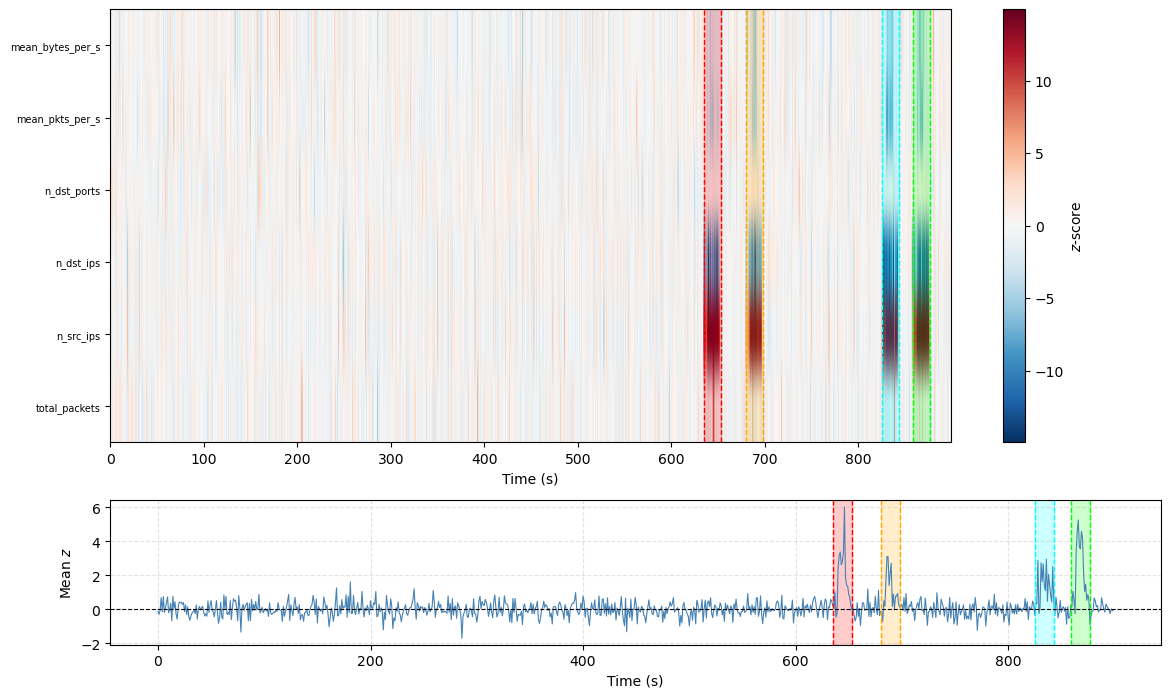

In [34]:
def plot_zscore_image(z_raw, t_axis, burst_iv=None, title=""):
    
    cm = 1/2.54
    
    fig, axes = plt.subplots(2, 1, figsize=(30*cm, 18*cm), gridspec_kw={'height_ratios': [3, 1]})
    
    # panel 1: z-score heatmap
    vmax = np.percentile(np.abs(z_raw), 99)
    im = axes[0].imshow(
        z_raw.T,
        aspect='auto',
        origin='lower',
        extent=[t_axis[0], t_axis[-1], -0.5, num_features - 0.5],
        cmap='RdBu_r',
        vmin=-vmax, vmax=vmax
    )
    axes[0].set_yticks(np.arange(num_features))
    axes[0].set_yticklabels(feature_names, fontsize=7)
    axes[0].set_xlabel("Time (s)")
    plt.colorbar(im, ax=axes[0], label="$z$-score")
    
    if burst_iv is not None:                   
        add_burst_shading(axes[0], burst_iv)

    # panel 2: mean z-score across features
    mean_z = z_raw.mean(axis=1)
    axes[1].plot(t_axis, mean_z, color='steelblue', lw=0.8)
    axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
    axes[1].set_ylabel(r"Mean $z$")
    axes[1].set_xlabel("Time (s)")
    axes[1].xaxis.grid(alpha=0.35, linestyle='dashed')
    axes[1].yaxis.grid(alpha=0.35, linestyle='dashed')
    
    if burst_iv is not None:                     
        add_burst_shading(axes[1], burst_iv)
    
    fig.savefig("image with z-score.png", dpi = 200)
    plt.tight_layout()
    plt.show()


# Build benign baseline
mu, sigma = build_benign_baseline(benign_train_dir)

attack_path = attack_train_dir / "attack_train_04.csv"
z_raw, z_norm, t_axis, df_attack = compute_zscore_image(attack_path, mu, sigma)

t_min_ms  = int(df_attack['FLOW_START_MILLISECONDS'].min() // bin_size_ms * bin_size_ms)
burst_iv  = extract_burst_intervals(df_attack, t_min_ms) 

print(f"Burst intervals:\n{burst_iv[['burst_id', 't_start_s', 't_end_s']]}")

plot_zscore_image(z_raw, t_axis, burst_iv=burst_iv, title=f"z-score image — {attack_path.name}")

## (2) Quanvolution with Random Circuit

In [36]:
PATCH_T = 2    # patch width  in time dimension
PATCH_F = 3    # patch height in feature dimension
N_QUBITS = PATCH_T * PATCH_F   # = 6  (derived, do not set manually)
N_LAYERS = 3    # depth of the random entangling circuit
N_CHANNELS = 4    # number of independent random circuits = output channels

dev = qml.device("lightning.qubit", wires=N_QUBITS)

np.random.seed(42)
rand_params = np.random.uniform(
    high=2 * np.pi,
    size=(N_CHANNELS, N_LAYERS, N_QUBITS)
)

In [37]:
@qml.qnode(dev)
def circuit(phi, channel):
    
    # angle encoding
    for j in range(N_QUBITS):
        qml.RY(np.pi * phi[j], wires=j)

    # random entangling circuit
    RandomLayers(rand_params[channel], wires=list(range(N_QUBITS)))

    # measure Z on each qubit
    return [qml.expval(qml.PauliZ(j)) for j in range(N_QUBITS)]

# Takes image shape (T, F), values in [0, 1] and returns shape (T - PATCH_T + 1, F - PATCH_F + 1, N_CHANNELS * N_QUBITS)
def quanvolutional_layer(image):

    T, F   = image.shape
    T_out  = T - PATCH_T + 1
    F_out  = F - PATCH_F + 1
    n_out  = N_CHANNELS * N_QUBITS

    output = np.zeros((T_out, F_out, n_out))
    total  = T_out * F_out
    count  = 0

    for t in range(T_out):
        for f in range(F_out):
            patch = image[t:t + PATCH_T, f:f + PATCH_F].flatten()  # (N_QUBITS,)

            channel_responses = []
            for c in range(N_CHANNELS):
                resp = circuit(patch, c)
                channel_responses.append(np.array(resp))

            output[t, f, :] = np.concatenate(channel_responses)

            count += 1
            if count % 200 == 0:
                print(f"  patch {count}/{total}", end='\r')

    print(f"  done: {total} patches processed")
    return output

# Takes output of quanvolution layer with shape shape (T_out, F_out, N_CHANNELS * N_QUBITS) and returns shape (T_out,), z-scored anomaly score per time bin
def anomaly_score(quanv_out):
    
    neg   = -quanv_out
    score = neg.mean(axis=(1, 2))
    score = (score - score.mean()) / (score.std() + 1e-9)
    return score

In [38]:
def run_pipeline(path, mu, sigma, z_thresh=2.0, coarsen=5):
    
    print(f"   PATCH_T={PATCH_T}, PATCH_F={PATCH_F}, "f"N_QUBITS={N_QUBITS}, N_LAYERS={N_LAYERS}, "f"N_CHANNELS={N_CHANNELS}")
    
    # z-score image
    z_raw, z_norm, t_axis, df = compute_zscore_image(path, mu, sigma)
    T, F = z_norm.shape

    t_min_ms = int(df['FLOW_START_MILLISECONDS'].min() // bin_size_ms * bin_size_ms)
    burst_iv = extract_burst_intervals(df, t_min_ms)

    # coarsen time axis
    T_c      = T // coarsen
    image_c  = (z_norm[:T_c * coarsen].reshape(T_c, coarsen, F).mean(axis=1))
    t_axis_c = (t_axis[:T_c * coarsen].reshape(T_c, coarsen).mean(axis=1))

    print(f"   Image after coarsening: {image_c.shape}  "f"({T_c} bins × {F} features)")
    
    # Check if patch fits inside image
    if T_c < PATCH_T or F < PATCH_F:
        raise ValueError(
            f"Patch ({PATCH_T}×{PATCH_F}) is larger than "
            f"coarsened image ({T_c}×{F}). "
            f"Reduce PATCH_T/PATCH_F or decrease coarsen."
        )

    # quanvolutional layer
    quanv_out = quanvolutional_layer(image_c)
    print(f"   Quanv output shape: {quanv_out.shape}")

    # anomaly score
    score   = anomaly_score(quanv_out)
    t_score = t_axis_c[:len(score)]
    flagged = score > z_thresh

    # suppress false positives on flat signals:
    # if the peak of the score is less than min_prominence
    # standard deviations above the mean, nothing is flagged
    min_prominence = 4.0
    score_range    = float(score.max() - score.mean())
    if score_range < min_prominence:
        flagged = np.zeros(len(flagged), dtype=bool)
        print(f"   Suppressed: peak prominence {score_range:.2f} < {min_prominence}")
    else:
        print(f"   Peak prominence: {score_range:.2f} — keeping flags")

    # plot
    cm = 1/2.54
    fig, axes = plt.subplots(3, 1, figsize=(30*cm, 24*cm), gridspec_kw={'height_ratios': [2, 1.5, 1]})
    
    # input image
    im = axes[0].imshow(
        image_c.T,
        aspect='auto', origin='lower',
        extent=[t_axis_c[0], t_axis_c[-1], -0.5, F - 0.5],
        cmap='RdBu_r', vmin=0, vmax=1
    )
    axes[0].set_yticks(np.arange(F))
    axes[0].set_yticklabels(feature_names, fontsize=7)
    axes[0].set_xlabel("Time (s)")
    plt.colorbar(im, ax=axes[0], label="Normalised $z$-score")
    
    if not burst_iv.empty:
        add_burst_shading(axes[0], burst_iv)

    # anomaly score
    axes[1].plot(t_score, score, color='steelblue', lw=0.9)
    axes[1].axhline(z_thresh, color='red', lw=1.2, linestyle='--', label=f'Threshold $z={z_thresh}$')
    axes[1].fill_between(t_score, score, z_thresh, where=flagged, color='red', alpha=0.4, label='Flagged')
    if not burst_iv.empty:
        add_burst_shading(axes[1], burst_iv)
    axes[1].set_ylabel("Anomaly score")
    axes[1].set_xlabel("Time (s)")
    axes[1].legend(loc='upper right', fontsize=7)
    axes[1].xaxis.grid(alpha=0.35, linestyle='dashed')
    axes[1].yaxis.grid(alpha=0.35, linestyle='dashed')
    
    fig.tight_layout()
    
        # binary output
    axes[2].fill_between(t_score, flagged.astype(int), step='mid', color='red', alpha=0.6, label='Flagged')
    if not burst_iv.empty:
        add_burst_shading(axes[2], burst_iv)
    axes[2].set_ylabel("Flagged")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_yticks([0, 1])
    axes[2].legend(loc='upper right', fontsize=7)
    axes[2].xaxis.grid(alpha=0.35, linestyle='dashed')
    axes[2].yaxis.grid(alpha=0.35, linestyle='dashed')
    
    fig.savefig("quanlayer_output.png", dpi = 200)
    return image_c, t_axis_c, score, flagged, burst_iv

   PATCH_T=2, PATCH_F=3, N_QUBITS=6, N_LAYERS=3, N_CHANNELS=4
   Image after coarsening: (180, 6)  (180 bins × 6 features)
  done: 716 patches processed
   Quanv output shape: (179, 4, 24)
   Suppressed: peak prominence 2.97 < 4.0


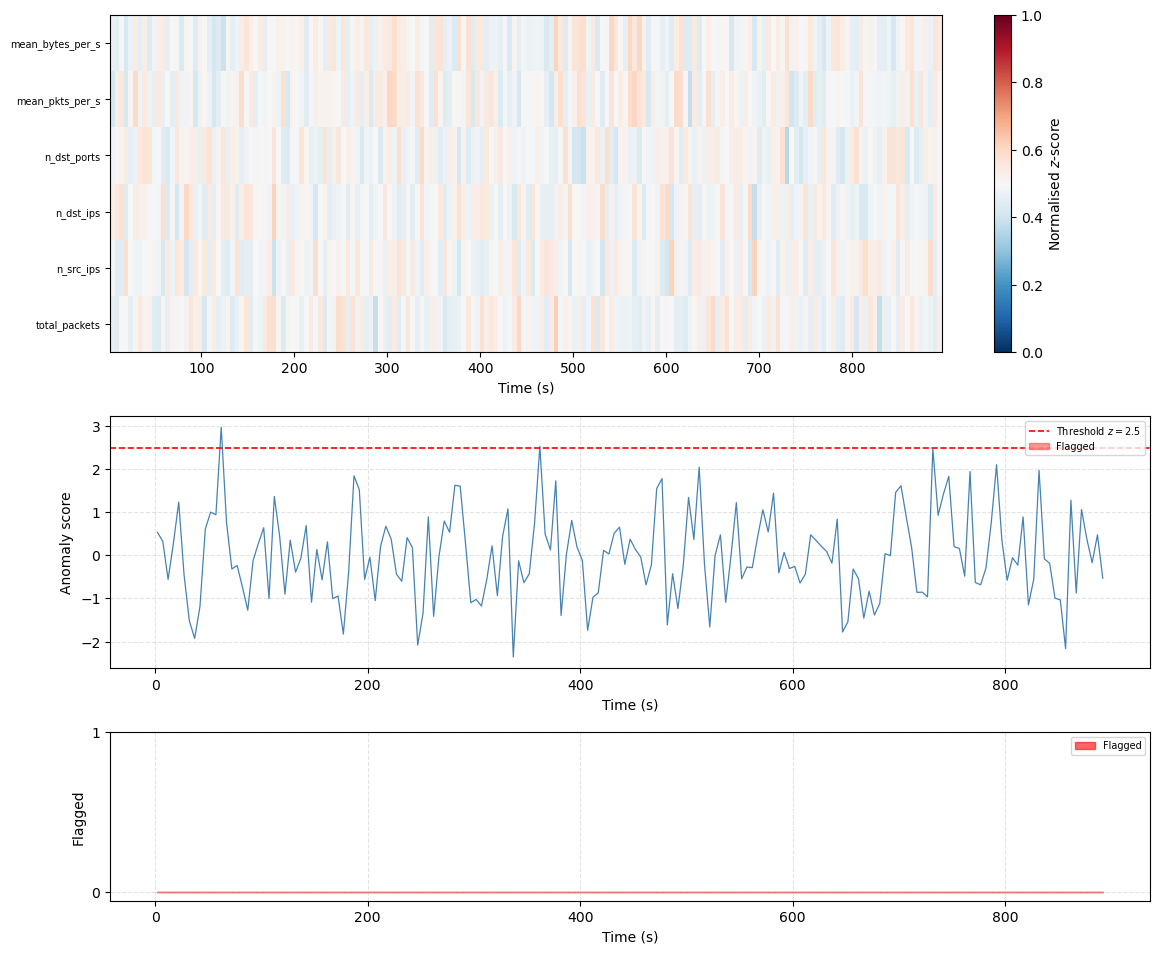

In [45]:
file_path = benign_train_dir / "normal_train_04.csv"

image_c, t_c, score, flagged, burst_iv = run_pipeline(
    file_path,
    mu, sigma,
    z_thresh = 2.5,
    coarsen  = 5
)

In [24]:
import itertools

def flagged_intervals(flagged, t_axis, coarsen = 5):

    t = t_axis[:len(flagged)]
    bin_width = coarsen  # seconds per coarsened bin

    intervals = []
    for is_flagged, group in itertools.groupby(
            enumerate(flagged), key=lambda x: x[1]):
        if is_flagged:
            indices = [i for i, _ in group]
            t_start = t[indices[0]]
            t_end   = t[indices[-1]] + bin_width  # end of last bin
            intervals.append({
                't_start_s':  t_start,
                't_end_s':    t_end,
                'duration_s': t_end - t_start
            })

    return pd.DataFrame(intervals)

detected_iv = flagged_intervals(flagged, t_c, coarsen=5)

In [25]:
flagged_intervals(flagged, t_c)

,t_start_s,t_end_s,duration_s
0,37.0,57.0,20.0
1,92.0,107.0,15.0


## (3) Training Quanvolution

In [26]:
PATCH_T = 2    # patch width  in time dimension
PATCH_F = 3    # patch height in feature dimension
N_QUBITS = PATCH_T * PATCH_F   # = 6  (derived, do not set manually)
N_LAYERS = 1    # depth of the random entangling circuit
N_CHANNELS = 1    # number of independent random circuits = output channels

dev = qml.device("lightning.qubit", wires=N_QUBITS)

np.random.seed(42)
rand_params = np.random.uniform(
    high=2 * np.pi,
    size=(N_CHANNELS, N_LAYERS, N_QUBITS)
)

In [27]:
X_list = []
y_list = []

# benign files → all bins labelled 0
for path in sorted(benign_train_dir.glob("*.csv")):
    z_raw, z_norm, t_axis, df = compute_zscore_image(path, mu, sigma)
    labels = np.zeros(len(t_axis), dtype=np.float32)
    X_list.append(z_norm)
    y_list.append(labels)

# attack files → bins labelled 1 where burst occurs
for path in sorted(attack_train_dir.glob("*.csv")):
    z_raw, z_norm, t_axis, df = compute_zscore_image(path, mu, sigma)
    t_min_ms = int(df['FLOW_START_MILLISECONDS'].min() // bin_size_ms * bin_size_ms)
    burst_iv = extract_burst_intervals(df, t_min_ms)

    labels = np.zeros(len(t_axis), dtype=np.float32)
    for _, row in burst_iv.iterrows():
        mask = (t_axis >= row['t_start_s']) & (t_axis <= row['t_end_s'])
        labels[mask] = 1.0

    X_list.append(z_norm)
    y_list.append(labels)

X_train = np.array(X_list)   # list of 16 arrays, each shape (T, F)
y_train = np.array(y_list)   # list of 16 arrays, each shape (T,)

# shuffle consistently so X and y stay aligned
rng = np.random.default_rng(seed=42)
idx = rng.permutation(len(X_train))
X_train = X_train[idx]
y_train = y_train[idx]

Epoch  1/50  loss=1.5034
Epoch  2/50  loss=1.4941
Epoch  3/50  loss=1.4856
Epoch  4/50  loss=1.4776
Epoch  5/50  loss=1.4699
Epoch  6/50  loss=1.4621
Epoch  7/50  loss=1.4541
Epoch  8/50  loss=1.4458
Epoch  9/50  loss=1.4371
Epoch 10/50  loss=1.4279
Epoch 11/50  loss=1.4184
Epoch 12/50  loss=1.4086
Epoch 13/50  loss=1.3988
Epoch 14/50  loss=1.3894
Epoch 15/50  loss=1.3808
Epoch 16/50  loss=1.3734
Epoch 17/50  loss=1.3672
Epoch 18/50  loss=1.3623
Epoch 19/50  loss=1.3584
Epoch 20/50  loss=1.3554
Epoch 21/50  loss=1.3531
Epoch 22/50  loss=1.3513
Epoch 23/50  loss=1.3499
Epoch 24/50  loss=1.3487
Epoch 25/50  loss=1.3478
Epoch 26/50  loss=1.3471
Epoch 27/50  loss=1.3465
Epoch 28/50  loss=1.3459
Epoch 29/50  loss=1.3455
Epoch 30/50  loss=1.3451
Epoch 31/50  loss=1.3447
Epoch 32/50  loss=1.3444
Epoch 33/50  loss=1.3442
Epoch 34/50  loss=1.3439
Epoch 35/50  loss=1.3437
Epoch 36/50  loss=1.3435
Epoch 37/50  loss=1.3434
Epoch 38/50  loss=1.3432
Epoch 39/50  loss=1.3431
Epoch 40/50  loss=1.3429


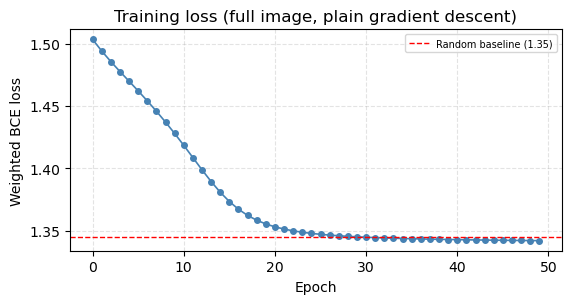

Trained parameters saved to theta_trained.npy


In [ ]:
PATCH_T    = 2
PATCH_F    = 3
N_QUBITS   = PATCH_T * PATCH_F   # = 6
N_LAYERS   = 1
N_CHANNELS = 1
COARSEN    = 5

n_total  = y_train.size
n_benign = float((y_train == 0).sum())
n_burst  = float((y_train == 1).sum())
pos_weight = n_benign / n_burst
baseline = np.log(2) * (pos_weight * n_burst + n_benign) / n_total


dev = qml.device("lightning.qubit", wires=N_QUBITS)

np.random.seed(42)
theta = pnp.array(
    np.random.uniform(0, 2 * np.pi,
                      size=(N_CHANNELS, N_LAYERS, 2, N_QUBITS)),
    requires_grad=True
)


@qml.qnode(dev, interface="autograd", diff_method="parameter-shift")
def circuit(phi, theta):
    """
    phi   : shape (N_QUBITS,)             — input patch, fixed
    theta : shape (N_LAYERS, 2, N_QUBITS) — trainable parameters

    Structure per layer:
        1. trainable Ry rotations         (pre-entanglement)
        2. CNOT ring                      (entanglement)
        3. re-upload input                (data after entanglement)
        4. trainable Ry rotations         (post-entanglement)
    """
    for l in range(N_LAYERS):
        for j in range(N_QUBITS):
            qml.RY(theta[l, 0, j], wires=j)

        for j in range(N_QUBITS):
            qml.CNOT(wires=[j, (j + 1) % N_QUBITS])

        for j in range(N_QUBITS):
            qml.RY(np.pi * phi[j], wires=j)

        for j in range(N_QUBITS):
            qml.RY(theta[l, 1, j], wires=j)

    return [qml.expval(qml.PauliZ(j)) for j in range(N_QUBITS)]


def quanvolutional_layer(image, theta):
    T, F  = image.shape
    T_out = T - PATCH_T + 1
    F_out = F - PATCH_F + 1

    all_responses = []
    for t in range(T_out):
        row_responses = []
        for f in range(F_out):
            patch = image[t:t + PATCH_T, f:f + PATCH_F].flatten()
            channel_responses = []
            for c in range(N_CHANNELS):
                resp = circuit(patch, theta[c])
                channel_responses.append(pnp.stack(resp))
            patch_out = pnp.concatenate(channel_responses)
            row_responses.append(patch_out)
        all_responses.append(pnp.stack(row_responses))
    return pnp.stack(all_responses)


def weighted_bce(theta, image_c, labels, pw=pos_weight):
    """
    Compute weighted BCE over the full coarsened image.

    theta   : shape (N_CHANNELS, N_LAYERS, 2, N_QUBITS)
    image_c : shape (T_c, F)
    labels  : shape (T_out,)   aligned to quanv output length
    """
    quanv_out = quanvolutional_layer(image_c, theta)

    score = -pnp.mean(quanv_out, axis=(1, 2))

    prob  = 1.0 / (1.0 + pnp.exp(-score))

    eps   = 1e-7
    bce   = -(pw * labels * pnp.log(prob + eps) +
              (1.0 - labels) * pnp.log(1.0 - prob + eps))
    return pnp.mean(bce)


def coarsen_image_and_labels(z_norm, labels, coarsen=5):
    T, F  = z_norm.shape
    T_c   = T // coarsen

    image_c  = (z_norm[:T_c * coarsen]
                .reshape(T_c, coarsen, F)
                .mean(axis=1))

    labels_c = (labels[:T_c * coarsen]
                .reshape(T_c, coarsen)
                .max(axis=1)
                .astype(np.float32))

    return image_c, labels_c

from pennylane import grad as qgrad

LEARNING_RATE = 0.2
N_EPOCHS      = 50

grad_fn      = qgrad(weighted_bce, argnums=0)
loss_history = []

for epoch in range(N_EPOCHS):
    epoch_loss = 0.0

    for image_raw, labels_raw in zip(X_train, y_train):

        image_c, labels_c = coarsen_image_and_labels(image_raw, labels_raw)

        n              = image_c.shape[0] - PATCH_T + 1
        labels_aligned = pnp.array(labels_c[:n], requires_grad=False)

        grads = grad_fn(theta, image_c, labels_aligned)

        theta = theta - LEARNING_RATE * grads

        loss_val    = float(weighted_bce(theta, image_c, labels_aligned))
        epoch_loss += loss_val

    epoch_loss /= len(X_train)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1:2d}/{N_EPOCHS}  loss={epoch_loss:.4f}")


cm_unit = 1/2.54
fig, ax = plt.subplots(figsize=(15*cm_unit, 8*cm_unit))
ax.plot(loss_history, color='steelblue', lw=1.2, marker='o', markersize=4)
ax.axhline(baseline, color='red', lw=1.0, linestyle='--',
           label=f'Random baseline ({baseline:.2f})')
ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted BCE loss")
ax.set_title("Training loss (full image, plain gradient descent)")
ax.legend(fontsize=7)
ax.xaxis.grid(alpha=0.35, linestyle='dashed')
ax.yaxis.grid(alpha=0.35, linestyle='dashed')
plt.tight_layout()
plt.show()

# save trained parameters
np.save("theta_trained.npy", np.array(theta))
print("Trained parameters saved to theta_trained.npy")

In [31]:
# evaluate loss at random initialisation (before any training)
# use the theta before the training loop starts
theta_init = pnp.array(
    np.random.uniform(0, 2 * np.pi,
                      size=(N_CHANNELS, N_LAYERS, 2, N_QUBITS)),
    requires_grad=False
)

init_loss = 0.0
for image_raw, labels_raw in zip(X_train, y_train):
    image_c, labels_c = coarsen_image_and_labels(image_raw, labels_raw)
    n              = image_c.shape[0] - PATCH_T + 1
    labels_aligned = pnp.array(labels_c[:n], requires_grad=False)
    init_loss += float(weighted_bce(theta_init, image_c, labels_aligned))

init_loss /= len(X_train)
print(f"Loss at random initialisation: {init_loss:.4f}")

Loss at random initialisation: 1.5006


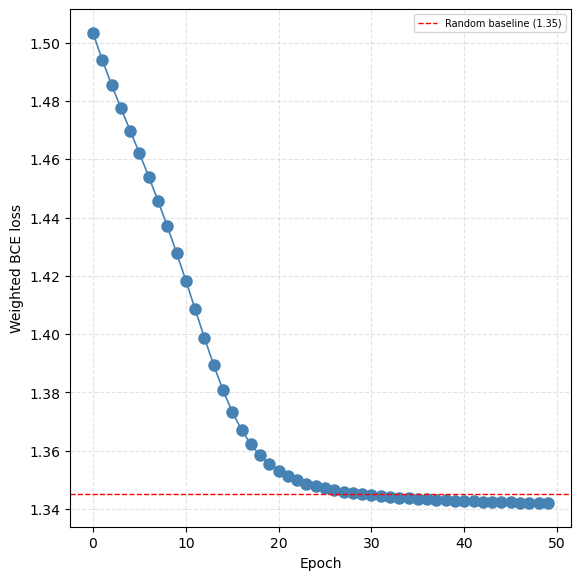

Trained parameters saved to theta_trained.npy


In [33]:
cm_unit = 1/2.54
fig, ax = plt.subplots(figsize=(15*cm_unit, 15*cm_unit))
ax.plot(loss_history, color='steelblue', lw=1.2, marker='o', ms = 8)
ax.axhline(baseline, color='red', lw=1.0, linestyle='--',
           label=f'Random baseline ({baseline:.2f})')
ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted BCE loss")
ax.legend(fontsize=7)
ax.xaxis.grid(alpha=0.35, linestyle='dashed')
ax.yaxis.grid(alpha=0.35, linestyle='dashed')
plt.tight_layout()
plt.show()

# save trained parameters
np.save("theta_trained.npy", np.array(theta))
print("Trained parameters saved to theta_trained.npy")

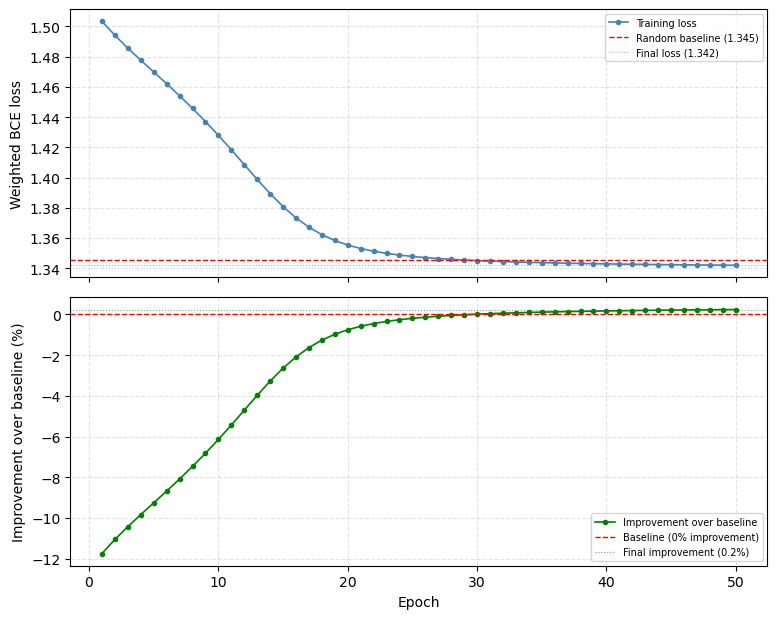

Initial loss:              1.5034
Final loss:                1.3420
Random baseline:           1.3453
Improvement over baseline: 0.2%
Loss reduction:            10.7%


In [48]:
cm_unit = 1/2.54

fig, axes = plt.subplots(2, 1, figsize=(20*cm_unit, 16*cm_unit),
                          sharex=True)

# ── panel 1: absolute loss vs baseline ───────────────────────────────────────
axes[0].plot(range(1, len(loss_history) + 1), loss_history,
             color='steelblue', lw=1.2, marker='o',
             markersize=3, label='Training loss')
axes[0].axhline(baseline, color='red', lw=1.0, linestyle='--',
                label=f'Random baseline ({baseline:.3f})')
axes[0].axhline(loss_history[-1], color='steelblue', lw=0.8,
                linestyle=':', alpha=0.6,
                label=f'Final loss ({loss_history[-1]:.3f})')
axes[0].set_ylabel("Weighted BCE loss")
axes[0].legend(fontsize=7, loc='upper right')
axes[0].xaxis.grid(alpha=0.35, linestyle='dashed')
axes[0].yaxis.grid(alpha=0.35, linestyle='dashed')

# ── panel 2: percentage improvement over baseline ─────────────────────────────
pct_improvement = [(baseline - l) / baseline * 100 for l in loss_history]
axes[1].plot(range(1, len(loss_history) + 1), pct_improvement,
             color='green', lw=1.2, marker='o', markersize=3,
             label='Improvement over baseline')
axes[1].axhline(0, color='red', lw=1.0, linestyle='--',
                label='Baseline (0% improvement)')
axes[1].axhline(pct_improvement[-1], color='green', lw=0.8,
                linestyle=':', alpha=0.6,
                label=f'Final improvement ({pct_improvement[-1]:.1f}%)')
axes[1].set_ylabel("Improvement over baseline (%)")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=7, loc='lower right')
axes[1].xaxis.grid(alpha=0.35, linestyle='dashed')
axes[1].yaxis.grid(alpha=0.35, linestyle='dashed')

fig.savefig("loss_plot.png", dpi = 200)
plt.tight_layout()
plt.show()

# ── print summary ─────────────────────────────────────────────────────────────
print(f"Initial loss:              {loss_history[0]:.4f}")
print(f"Final loss:                {loss_history[-1]:.4f}")
print(f"Random baseline:           {baseline:.4f}")
print(f"Improvement over baseline: {pct_improvement[-1]:.1f}%")
print(f"Loss reduction:            {(loss_history[0] - loss_history[-1]) / loss_history[0] * 100:.1f}%")